Step 1 — Create the dataset

In [1]:
import pandas as pd

data = {
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
                    6, 7, 7, 8, 8, 9, 9, 10],
    
    "attendance": [50, 55, 60, 62, 65, 68, 70, 72, 75, 78,
                   80, 82, 85, 87, 90, 92, 94, 96],
    
    "passed": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
               1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

df

,study_hours,attendance,passed
0,1,50,0
1,2,55,0
2,2,60,0
3,3,62,0
4,3,65,0
5,4,68,1
6,4,70,1
7,5,72,1
8,5,75,1
9,6,78,1


Step 2 — Separate Features (X) and Target (y)

In [2]:
X = df[["study_hours", "attendance"]]
y = df["passed"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
    study_hours  attendance
0             1          50
1             2          55
2             2          60
3             3          62
4             3          65
5             4          68
6             4          70
7             5          72
8             5          75
9             6          78
10            6          80
11            7          82
12            7          85
13            8          87
14            8          90
15            9          92
16            9          94
17           10          96

Target (y):
0     0
1     0
2     0
3     0
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
Name: passed, dtype: int64


Step 3 — Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (14, 2)
Testing features: (4, 2)
Training target: (14,)
Testing target: (4,)


Step 4 — Feature Scaling

In [6]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [7]:
#Create the scaler
scaler = StandardScaler()

In [8]:
# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

In [9]:
# Scale the test data
X_test_scaled = scaler.transform(X_test)

In [10]:
# Look at the result
print("Original Training Data:")
print(X_train)

print("\nScaled Training Data:")
print(X_train_scaled)

Original Training Data:
    study_hours  attendance
3             3          62
13            8          87
16            9          94
15            9          92
11            7          82
2             2          60
9             6          78
17           10          96
4             3          65
12            7          85
7             5          72
10            6          80
14            8          90
6             4          70

Scaled Training Data:
[[-1.32525014 -1.50715732]
 [ 0.73625008  0.64592456]
 [ 1.14855012  1.24878749]
 [ 1.14855012  1.07654094]
 [ 0.32395004  0.21530819]
 [-1.73755019 -1.67940387]
 [-0.08835001 -0.12918491]
 [ 1.56085017  1.42103404]
 [-1.32525014 -1.24878749]
 [ 0.32395004  0.47367801]
 [-0.50065005 -0.64592456]
 [-0.08835001  0.04306164]
 [ 0.73625008  0.90429439]
 [-0.9129501  -0.81817112]]


Step 5 — Build the Neural Network

In [11]:
# Step 5.1 — Import TensorFlow
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1790509790.283005   23602 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790509790.284594   23602 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790509790.759104   23602 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790509793.592457   23602 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2.21.0


In [12]:
# Step 5.2 — Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/home/tahir_zaman/anaconda3/envs/deeplearning/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790509873.063678   23602 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1790509873.065797   24739 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790509873.090731   23602 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if yo

In [13]:
# Step 5.3 — View the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Step 6 — Compile the Neural Network

In [ ]:
# Step 6.1 — Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# Step 7 — Train the Neural Network
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.1818 - loss: 0.7952 - val_accuracy: 0.6667 - val_loss: 0.6740
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1818 - loss: 0.7845 - val_accuracy: 0.6667 - val_loss: 0.6734
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1818 - loss: 0.7719 - val_accuracy: 0.6667 - val_loss: 0.6723
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1818 - loss: 0.7598 - val_accuracy: 0.6667 - val_loss: 0.6714
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1818 - loss: 0.7494 - val_accuracy: 0.6667 - val_loss: 0.6706
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2727 - loss: 0.7408 - val_accuracy: 0.6667 - val_loss: 0.6710
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3636 - loss: 0.7292 - val_accuracy: 0.6667 - val_loss: 0.6710
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4545 - loss: 0.7208 - val_accuracy: 1.0000 - val_loss: 0.6715


Step 8 — Evaluate the Model on Test Data

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5679827928543091
Test Accuracy: 0.5


Step 9 — Make Predictions on New Students

In [ ]:
# Step 9.1 — Create new inputs
import numpy as np

new_students = np.array([
    [2, 55],
    [6, 80],
    [9, 95]
])

new_students

array([[ 2, 55],
       [ 6, 80],
       [ 9, 95]])

In [19]:
# Step 9.2 — Scale the new inputs]
new_students_scaled = scaler.transform(new_students)

new_students_scaled

/home/tahir_zaman/anaconda3/envs/deeplearning/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-1.73755019, -2.11002024],
       [-0.08835001,  0.04306164],
       [ 1.14855012,  1.33491077]])

In [20]:
# Step 9.3 — Get predictions
predictions = model.predict(new_students_scaled)

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[0.15803105],
       [0.5846096 ],
       [0.8020859 ]], dtype=float32)

In [21]:
# Step 9.4 — Convert probabilities to Pass/Fail
for i, prediction in enumerate(predictions):
    probability = prediction[0]
    result = "Pass" if probability >= 0.5 else "Fail"

    print(
        f"Student {i+1}: "
        f"Study Hours = {new_students[i][0]}, "
        f"Attendance = {new_students[i][1]}%, "
        f"Probability = {probability:.2f}, "
        f"Prediction = {result}"
    )

Student 1: Study Hours = 2, Attendance = 55%, Probability = 0.16, Prediction = Fail
Student 2: Study Hours = 6, Attendance = 80%, Probability = 0.58, Prediction = Pass
Student 3: Study Hours = 9, Attendance = 95%, Probability = 0.80, Prediction = Pass


Step 10 — Accuracy and Loss Graphs

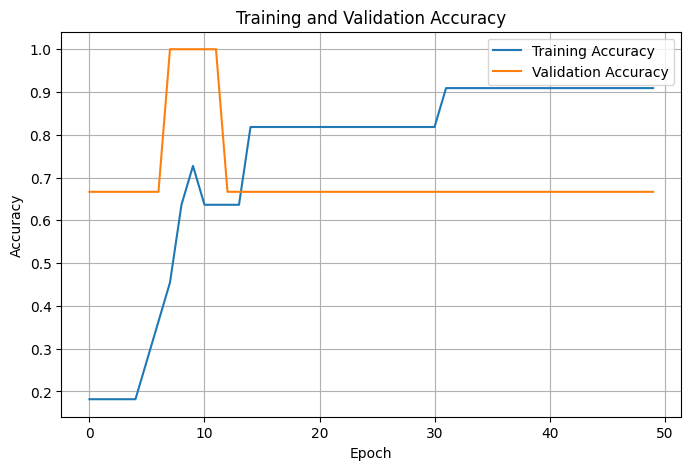

In [22]:
# Step 10.1 — Accuracy Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

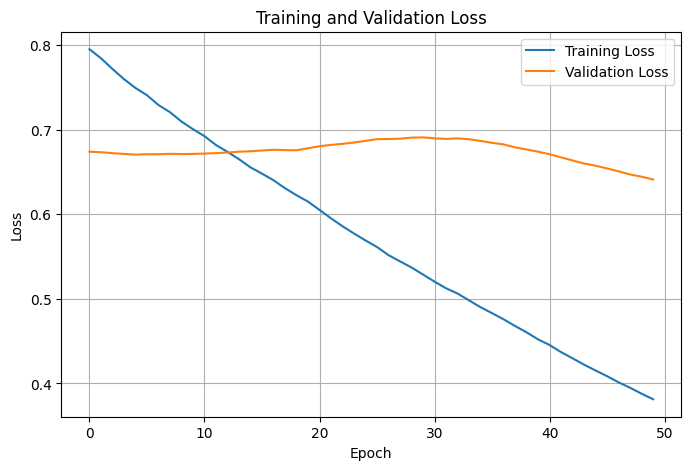

In [23]:
# Step 10.2 — Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()